In [1]:

from analysis import *

TARGET_FEATURES = [
    "TWS",
    "central",
    "COG_Mag",
    "Heel_Abs",
    "lateral",
    "ROT",
    "Trim",
    "TWA_Abs",
    "boat_weight",
    "SOG",
]



df = pd.read_csv("all_data.csv")
drop_cols = [c for c in df.columns if c not in TARGET_FEATURES]
MAX_NULL_RATIO = 0.2

### II.1. All upwind data

In [2]:
upwind_data = df[df['TWA'] >= 0]
df_numeric_upwind = upwind_data.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_upwind.drop(columns=[c for c in drop_cols if c in df_numeric_upwind.columns], inplace=True)
df_numeric_upwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_upwind)}")

Number of rows after filtering: 44750



Initial features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Selected features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Data cleaning:
- Initial samples: 44750
- Removed samples with NaNs: 6725
- Final samples: 38025

Correlation with SOG:


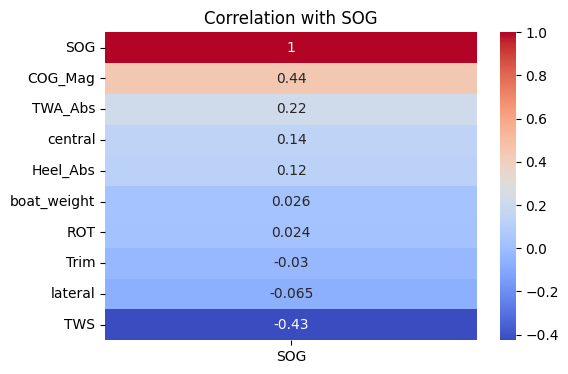


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
COG_Mag,2380.837436,1.0,3283.219642,0.000000e+00,0.079500
TWS,955.883266,1.0,1318.181018,9.131634e-284,0.033513
TWA_Abs,900.750358,1.0,1242.151700,8.804776e-268,0.031641
lateral,529.338163,1.0,729.967291,2.924818e-159,0.018840
boat_weight,496.564858,1.0,684.772287,1.301300e-149,0.017694
central,217.935349,1.0,300.536949,4.561542e-67,0.007844
Trim,46.001322,1.0,63.436689,1.701816e-15,0.001666
ROT,14.182982,1.0,19.558599,9.783098e-06,0.000514
Heel_Abs,0.064701,1.0,0.089224,7.651680e-01,0.000002
Residual,27566.701290,38015.0,NaN,NaN,0.500000



Polynomial fit:
R²: 0.281

Top coefficients:
    feature  coefficient
boat_weight    -0.558210
        TWS    -0.069111
    lateral    -0.062764
    COG_Mag     0.020203
    TWA_Abs     0.017682
       Trim    -0.010738
    central     0.004138
        ROT     0.001046
   Heel_Abs     0.000245


,feature,coefficient
8,boat_weight,-0.558210
0,TWS,-0.069111
4,lateral,-0.062764
2,COG_Mag,0.020203
7,TWA_Abs,0.017682
6,Trim,-0.010738
1,central,0.004138
5,ROT,0.001046
3,Heel_Abs,0.000245


In [3]:
full_analysis(df_numeric_upwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

### II.2. Upwind: Gian vs Max
#### II.2.1. Upwind: Gian

In [4]:
Gian_data_upwind = upwind_data[(upwind_data['boat_name'] == "Gian Stragiotti")]
df_numeric_Gian_upwind = Gian_data_upwind.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_Gian_upwind.drop(columns=[c for c in drop_cols if c in df_numeric_Gian_upwind.columns], inplace=True)
df_numeric_Gian_upwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_Gian_upwind)}")

Number of rows after filtering: 20580



Initial features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Selected features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Data cleaning:
- Initial samples: 20580
- Removed samples with NaNs: 57
- Final samples: 20523

Correlation with SOG:


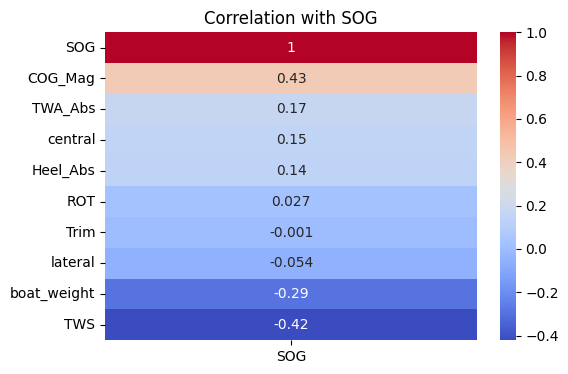


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
COG_Mag,1868.014778,1.0,2514.784128,0.000000e+00,0.109207
boat_weight,1397.014426,1.0,1880.707662,0.000000e+00,0.083984
TWS,518.065116,1.0,697.436630,3.614466e-151,0.032882
central,204.423478,1.0,275.201740,2.096309e-61,0.013238
lateral,153.905148,1.0,207.192271,9.513238e-47,0.010000
TWA_Abs,130.479430,1.0,175.655784,6.283979e-40,0.008490
Trim,55.316258,1.0,74.468601,6.602643e-18,0.003617
Heel_Abs,40.417687,1.0,54.411646,1.687813e-13,0.002646
ROT,0.132292,1.0,0.178096,6.730192e-01,0.000009
Residual,15237.326616,20513.0,NaN,NaN,0.500000



Polynomial fit:
R²: 0.330

Top coefficients:
    feature  coefficient
boat_weight    -5.851831
        TWS    -0.072976
    lateral    -0.057943
    COG_Mag     0.027195
       Trim    -0.017980
    TWA_Abs     0.009296
   Heel_Abs    -0.008382
    central     0.005409
        ROT     0.000133


,feature,coefficient
8,boat_weight,-5.851831
0,TWS,-0.072976
4,lateral,-0.057943
2,COG_Mag,0.027195
6,Trim,-0.017980
7,TWA_Abs,0.009296
3,Heel_Abs,-0.008382
1,central,0.005409
5,ROT,0.000133


In [5]:
full_analysis(df_numeric_Gian_upwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

#### II.2.2. Upwind: max

In [6]:
Max_data_upwind = upwind_data[(upwind_data['boat_name'] == "Max Maeder")]
df_numeric_Max_upwind = Max_data_upwind.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_Max_upwind.drop(columns=[c for c in drop_cols if c in df_numeric_Max_upwind.columns], inplace=True)
df_numeric_Max_upwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_Max_upwind)}")

Number of rows after filtering: 24170


In [7]:
Max_data_upwind.sample(10)

,ISODateTimeUTC,SecondsSince1970,SOG,TWA,TWS,TWD,BelowLineCalc,central,COG,COG_Mag,...,boat_name,opponent_name,boat_role,boat_weight,interval_duration,mast_brand,load_cell,pol_ratio,SOG_ref,leg_type
12041,2025-11-26T12:38:12.349Z,1.764161e+09,22.0,29.440,19.205,329.340,NaN,125.785,299.9,296.9,...,Max Maeder,Gian Stragiotti,master,111.5,95.700,Levi,2,97.177453,22.834064,upwind
65752,2025-11-27T08:47:47.073Z,1.764233e+09,22.4,25.363,17.270,340.063,NaN,140.561,314.7,311.7,...,Max Maeder,Gian Stragiotti,slave,111.4,100.703,Chub,2,99.178917,22.895631,upwind
12453,2025-11-26T12:38:53.558Z,1.764161e+09,22.8,26.167,20.688,332.467,NaN,115.644,306.3,303.3,...,Max Maeder,Gian Stragiotti,master,111.5,95.700,Levi,2,97.177453,22.834064,upwind
2610,2025-11-25T14:00:43.760Z,1.764079e+09,21.1,25.572,21.380,288.372,NaN,91.900,262.8,259.8,...,Max Maeder,Gian Stragiotti,master,111.5,64.483,Levi,2,94.829584,22.864497,upwind
39522,2025-11-26T14:22:37.052Z,1.764167e+09,22.1,27.411,11.595,332.611,NaN,108.900,305.2,302.2,...,Max Maeder,Gian Stragiotti,slave,111.4,94.602,Chub,2,103.422583,22.427541,upwind
15096,2025-11-26T12:53:43.960Z,1.764162e+09,23.7,33.524,18.988,339.624,NaN,132.800,306.1,303.1,...,Max Maeder,Gian Stragiotti,slave,111.4,96.096,Chub,2,100.776616,22.837196,upwind
59646,2025-11-27T08:29:58.155Z,1.764232e+09,23.2,36.185,16.838,353.784,NaN,137.900,317.6,314.6,...,Max Maeder,Gian Stragiotti,slave,111.4,108.029,Chub,2,98.058035,22.947482,upwind
36521,2025-11-26T14:12:03.756Z,1.764166e+09,21.8,22.500,16.503,336.000,NaN,166.000,313.5,310.5,...,Max Maeder,Gian Stragiotti,master,111.4,97.804,Chub,2,97.920101,22.899160,upwind
30892,2025-11-26T13:46:08.844Z,1.764165e+09,22.3,31.838,15.823,338.538,NaN,120.000,306.7,303.7,...,Max Maeder,Gian Stragiotti,master,111.5,99.197,Levi,2,98.189128,22.808193,upwind
12548,2025-11-26T12:39:03.061Z,1.764161e+09,22.3,32.200,18.700,335.700,NaN,171.193,303.5,300.5,...,Max Maeder,Gian Stragiotti,master,111.5,95.700,Levi,2,97.177453,22.834064,upwind



Initial features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Removed features (> 20% NaN): ['lateral']

Selected features (8): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Data cleaning:
- Initial samples: 24170
- Removed samples with NaNs: 2545
- Final samples: 21625

Correlation with SOG:


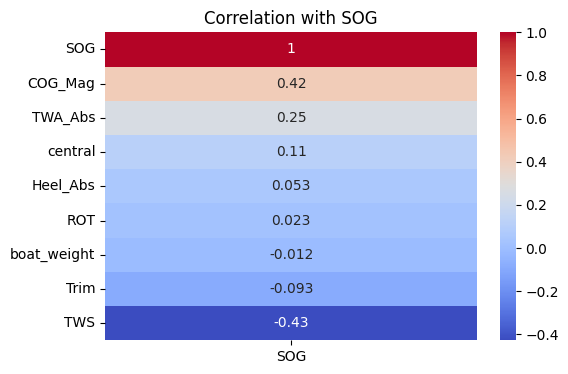


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
COG_Mag,910.001943,1.0,1493.572129,5.222993e-316,0.064630
TWA_Abs,485.872834,1.0,797.455575,2.575599e-172,0.035579
TWS,370.697180,1.0,608.419553,1.673705e-132,0.027376
Trim,67.303215,1.0,110.463727,8.948998e-26,0.005084
Heel_Abs,42.926584,1.0,70.454738,4.995216e-17,0.003249
boat_weight,10.586122,1.0,17.374839,3.080554e-05,0.000803
central,10.256347,1.0,16.833584,4.095425e-05,0.000778
ROT,4.388379,1.0,7.202578,7.285436e-03,0.000333
Residual,13170.172114,21616.0,NaN,NaN,0.500000



Polynomial fit:
R²: 0.263

Top coefficients:
    feature  coefficient
boat_weight     0.496804
        TWS    -0.058675
    TWA_Abs     0.017724
       Trim    -0.017095
    COG_Mag     0.016736
   Heel_Abs    -0.008980
    central     0.001156
        ROT     0.000807


,feature,coefficient
7,boat_weight,0.496804
0,TWS,-0.058675
6,TWA_Abs,0.017724
5,Trim,-0.017095
2,COG_Mag,0.016736
3,Heel_Abs,-0.008980
1,central,0.001156
4,ROT,0.000807


In [8]:
full_analysis(df_numeric_Max_upwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

#### II.2.3. Upwind: max vs Gian t_test

In [9]:
t_test(df_numeric_Gian_upwind,df_numeric_Max_upwind)

T-statistic: 30.699, p-value: 0.000000000000000
The difference is statistically significant, keeping data split.


### II.3. Upwind: Master vs Slave
#### II.3.1. Master

In [10]:
master_data_upwind = upwind_data[upwind_data['boat_role'] == "master"]
df_numeric_master_upwind = master_data_upwind.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_master_upwind.drop(columns=[c for c in drop_cols if c in df_numeric_master_upwind.columns], inplace=True)
df_numeric_master_upwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_master_upwind)}")

Number of rows after filtering: 22487



Initial features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Selected features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Data cleaning:
- Initial samples: 22487
- Removed samples with NaNs: 3150
- Final samples: 19337

Correlation with SOG:


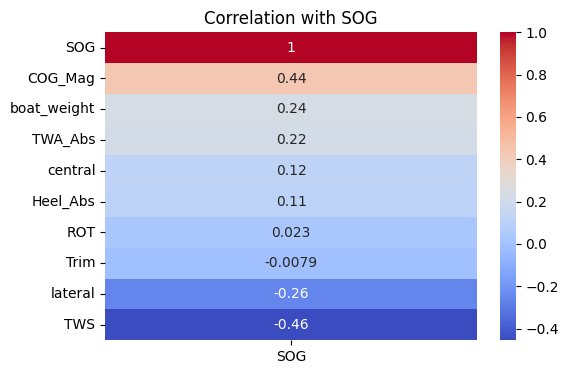


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
COG_Mag,849.225101,1.0,1251.209089,1.266390e-265,0.060803
TWS,799.672458,1.0,1178.200511,1.073929e-250,0.057459
lateral,362.429227,1.0,533.986505,1.453851e-116,0.026886
TWA_Abs,290.052067,1.0,427.349336,6.362458e-94,0.021633
central,136.072840,1.0,200.483446,2.759410e-45,0.010267
Trim,35.626585,1.0,52.490568,4.485795e-13,0.002709
boat_weight,11.260572,1.0,16.590808,4.656014e-05,0.000858
ROT,6.808954,1.0,10.031999,1.540832e-03,0.000519
Heel_Abs,1.108750,1.0,1.633581,2.012238e-01,0.000085
Residual,13117.690451,19327.0,NaN,NaN,0.500000



Polynomial fit:
R²: 0.323

Top coefficients:
    feature  coefficient
boat_weight    -0.120163
        TWS    -0.089901
    lateral    -0.074122
    COG_Mag     0.015695
    TWA_Abs     0.014275
       Trim    -0.013110
    central     0.004648
   Heel_Abs    -0.001414
        ROT     0.001010


,feature,coefficient
8,boat_weight,-0.120163
0,TWS,-0.089901
4,lateral,-0.074122
2,COG_Mag,0.015695
7,TWA_Abs,0.014275
6,Trim,-0.013110
1,central,0.004648
3,Heel_Abs,-0.001414
5,ROT,0.001010


In [11]:
full_analysis(df_numeric_master_upwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

#### II.3.2 Slave

In [12]:
slave_data_upwind = upwind_data[upwind_data['boat_role'] == "slave"]
df_numeric_slave_upwind = slave_data_upwind.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_slave_upwind.drop(columns=[c for c in drop_cols if c in df_numeric_slave_upwind.columns], inplace=True)
df_numeric_slave_upwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_slave_upwind)}")

Number of rows after filtering: 22263



Initial features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Selected features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Data cleaning:
- Initial samples: 22263
- Removed samples with NaNs: 3575
- Final samples: 18688

Correlation with SOG:


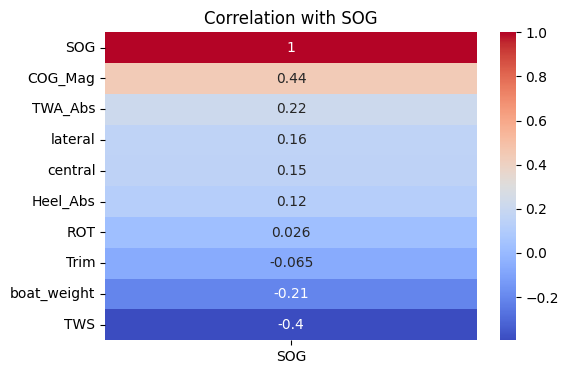


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
COG_Mag,1552.506225,1.0,2258.707302,0.000000e+00,0.107883
boat_weight,781.568983,1.0,1137.087594,4.956934e-242,0.057385
TWA_Abs,396.200766,1.0,576.423816,1.783024e-125,0.029937
TWS,207.478734,1.0,301.856265,4.373727e-67,0.015904
lateral,102.195123,1.0,148.681447,4.536406e-34,0.007897
central,44.116104,1.0,64.183553,1.199657e-15,0.003425
ROT,4.417884,1.0,6.427482,1.124486e-02,0.000344
Trim,3.920912,1.0,5.704450,1.693183e-02,0.000305
Heel_Abs,0.571652,1.0,0.831684,3.617979e-01,0.000045
Residual,12838.189018,18678.0,NaN,NaN,0.500000



Polynomial fit:
R²: 0.312

Top coefficients:
    feature  coefficient
boat_weight    -0.984242
        TWS    -0.045775
    lateral    -0.039299
    COG_Mag     0.025695
    TWA_Abs     0.016823
       Trim    -0.004549
    central     0.002635
   Heel_Abs     0.001051
        ROT     0.000838


,feature,coefficient
8,boat_weight,-0.984242
0,TWS,-0.045775
4,lateral,-0.039299
2,COG_Mag,0.025695
7,TWA_Abs,0.016823
6,Trim,-0.004549
1,central,0.002635
3,Heel_Abs,0.001051
5,ROT,0.000838


In [13]:
full_analysis(df_numeric_slave_upwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

#### III.3.3. Upwind: Master vs Slave t_test

In [14]:
t_test(df_numeric_master_upwind,df_numeric_slave_upwind)

T-statistic: -11.919, p-value: 0.000000000000000
The difference is statistically significant, keeping data split.


## III Downwind
### III.1. All downwind data

In [15]:
downwind_data = df[df['TWA'] < 0]
df_numeric_downwind = downwind_data.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_downwind.drop(columns=[c for c in drop_cols if c in df_numeric_downwind.columns], inplace=True)
df_numeric_downwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_downwind)}")

Number of rows after filtering: 32043



Initial features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Selected features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Data cleaning:
- Initial samples: 32043
- Removed samples with NaNs: 3732
- Final samples: 28311

Correlation with SOG:


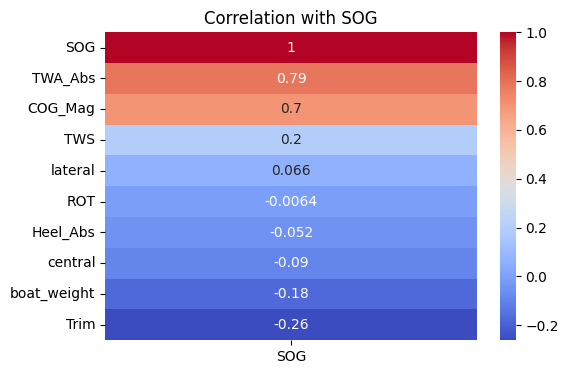


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
TWA_Abs,13910.215958,1.0,5402.160809,0.000000e+00,0.160286
COG_Mag,7889.736250,1.0,3064.051923,0.000000e+00,0.097690
TWS,4328.949108,1.0,1681.187358,0.000000e+00,0.056073
boat_weight,3973.413841,1.0,1543.111954,0.000000e+00,0.051706
Trim,3173.820661,1.0,1232.582559,2.388437e-264,0.041735
lateral,667.110386,1.0,259.078478,4.935216e-58,0.009071
central,163.907970,1.0,63.655174,1.537838e-15,0.002244
Heel_Abs,82.905012,1.0,32.196927,1.406705e-08,0.001136
ROT,52.715605,1.0,20.472592,6.073713e-06,0.000723
Residual,72873.251235,28301.0,NaN,NaN,0.500000



Polynomial fit:
R²: 0.710

Top coefficients:
    feature  coefficient
boat_weight    -2.294007
        TWS     0.203210
    lateral    -0.111862
       Trim    -0.106101
    TWA_Abs     0.076796
    COG_Mag     0.048516
   Heel_Abs     0.010944
    central     0.008127
        ROT    -0.003738


,feature,coefficient
8,boat_weight,-2.294007
0,TWS,0.203210
4,lateral,-0.111862
6,Trim,-0.106101
7,TWA_Abs,0.076796
2,COG_Mag,0.048516
3,Heel_Abs,0.010944
1,central,0.008127
5,ROT,-0.003738


In [16]:

full_analysis(df_numeric_downwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

### III.2. Downwind: Gian vs max
#### III.2.1. Downwind: Gian

In [17]:
gian_data_downwind = downwind_data[
    (downwind_data['boat_name'] == "Gian Stragiotti") |
    ((downwind_data['boat_name'] == "SenseBoard") & (downwind_data['opponent_name'] == "max Maeder"))
]
df_numeric_gian_downwind = gian_data_downwind.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_gian_downwind.drop(columns=[c for c in drop_cols if c in df_numeric_gian_downwind.columns], inplace=True)
df_numeric_gian_downwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_gian_downwind)}")

Number of rows after filtering: 15444



Initial features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Selected features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Data cleaning:
- Initial samples: 15444
- Removed samples with NaNs: 50
- Final samples: 15394

Correlation with SOG:


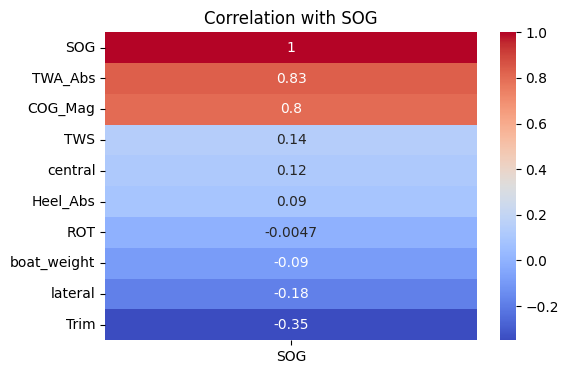


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
COG_Mag,11434.970058,1.0,5235.726183,0.000000e+00,0.253918
TWA_Abs,9316.041208,1.0,4265.532890,0.000000e+00,0.217081
boat_weight,7165.201735,1.0,3280.728689,0.000000e+00,0.175772
TWS,2064.862872,1.0,945.438121,1.544028e-201,0.057898
Trim,1190.306492,1.0,545.005263,1.746600e-118,0.034215
lateral,151.886785,1.0,69.544355,8.098664e-17,0.004500
ROT,43.121750,1.0,19.744142,8.915091e-06,0.001282
Heel_Abs,4.340415,1.0,1.987345,1.586390e-01,0.000129
central,4.308227,1.0,1.972606,1.601917e-01,0.000128
Residual,33599.079331,15384.0,NaN,NaN,0.500000



Polynomial fit:
R²: 0.811

Top coefficients:
    feature  coefficient
boat_weight   -15.149731
        TWS     0.196392
    lateral    -0.109087
       Trim    -0.093062
    TWA_Abs     0.088770
    COG_Mag     0.085507
        ROT    -0.004640
   Heel_Abs    -0.003578
    central    -0.002012


,feature,coefficient
8,boat_weight,-15.149731
0,TWS,0.196392
4,lateral,-0.109087
6,Trim,-0.093062
7,TWA_Abs,0.088770
2,COG_Mag,0.085507
5,ROT,-0.004640
3,Heel_Abs,-0.003578
1,central,-0.002012


In [18]:

full_analysis(df_numeric_gian_downwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

#### III.2.2. Downwind: max

In [19]:
Max_data_downwind = downwind_data[
    (downwind_data['boat_name'] == "Max Maeder") |
    ((downwind_data['boat_name'] == "SenseBoard") & (downwind_data['opponent_name'] == "Gian Stragiotti"))
]
df_numeric_Max_downwind = Max_data_downwind.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_Max_downwind.drop(columns=[c for c in drop_cols if c in df_numeric_Max_downwind.columns], inplace=True)
df_numeric_Max_downwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_Max_downwind)}")

Number of rows after filtering: 16599



Initial features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Removed features (> 20% NaN): ['lateral']

Selected features (8): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Data cleaning:
- Initial samples: 16599
- Removed samples with NaNs: 777
- Final samples: 15822

Correlation with SOG:


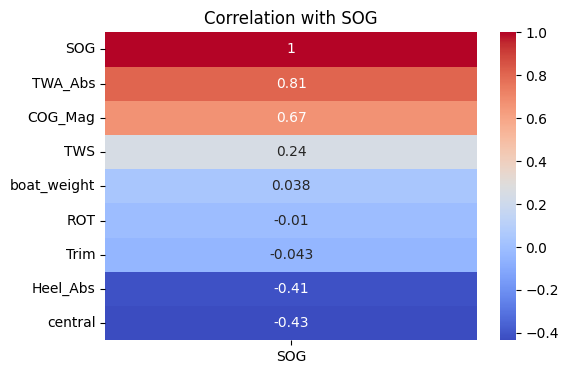


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
TWA_Abs,4471.314017,1.0,3426.985284,0.000000e+00,0.178118
COG_Mag,1657.619678,1.0,1270.462826,1.026400e-267,0.074368
boat_weight,1134.399106,1.0,869.446661,4.498795e-186,0.052117
TWS,765.013081,1.0,586.335149,3.218720e-127,0.035754
Heel_Abs,266.350962,1.0,204.141517,5.041747e-46,0.012745
central,63.007418,1.0,48.291284,3.817273e-12,0.003045
Trim,37.758547,1.0,28.939588,7.573342e-08,0.001827
ROT,1.212334,1.0,0.929179,3.350912e-01,0.000059
Residual,20631.803963,15813.0,NaN,NaN,0.500000



Polynomial fit:
R²: 0.713

Top coefficients:
    feature  coefficient
boat_weight     5.784335
        TWS     0.120132
    TWA_Abs     0.058714
    COG_Mag     0.028879
   Heel_Abs    -0.028323
       Trim    -0.018419
    central    -0.006333
        ROT    -0.000762


,feature,coefficient
7,boat_weight,5.784335
0,TWS,0.120132
6,TWA_Abs,0.058714
2,COG_Mag,0.028879
3,Heel_Abs,-0.028323
5,Trim,-0.018419
1,central,-0.006333
4,ROT,-0.000762


In [20]:
full_analysis(df_numeric_Max_downwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

#### III.2.3. Downwind: Max vs Gian t_test

In [21]:
t_test(df_numeric_Max_downwind,df_numeric_gian_downwind)

T-statistic: 28.132, p-value: 0.000000000000000
The difference is statistically significant, keeping data split.


### III.3. Downwind: Master vs Slave
#### III.3.1 Downwind Master

In [22]:
master_data_downwind = downwind_data[downwind_data['boat_role'] == "master"]
df_numeric_master_downwind = master_data_downwind.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_master_downwind.drop(columns=[c for c in drop_cols if c in df_numeric_master_downwind.columns], inplace=True)
df_numeric_master_downwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_master_downwind)}")

Number of rows after filtering: 16043



Initial features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Selected features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Data cleaning:
- Initial samples: 16043
- Removed samples with NaNs: 1844
- Final samples: 14199

Correlation with SOG:


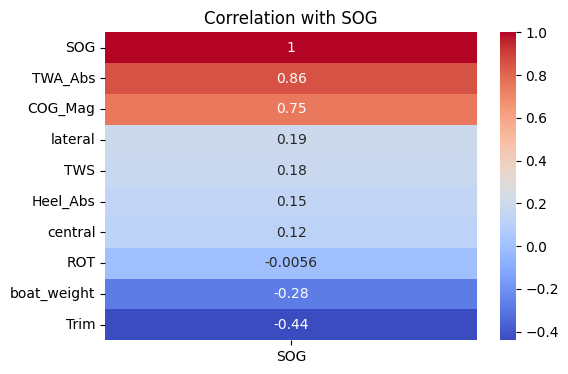


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
TWA_Abs,16426.398841,1.0,7218.016399,0.000000e+00,0.337180
COG_Mag,4401.131605,1.0,1933.926018,0.000000e+00,0.119949
boat_weight,2849.845653,1.0,1252.266723,6.054226e-263,0.081099
TWS,851.671982,1.0,374.237981,2.560488e-82,0.025697
Trim,630.897459,1.0,277.226205,1.160903e-61,0.019164
lateral,114.905427,1.0,50.491241,1.254043e-12,0.003546
central,67.964431,1.0,29.864633,4.711030e-08,0.002100
Heel_Abs,55.079339,1.0,24.202722,8.768168e-07,0.001703
ROT,36.320405,1.0,15.959754,6.503013e-05,0.001124
Residual,32290.612863,14189.0,NaN,NaN,0.500000



Polynomial fit:
R²: 0.820

Top coefficients:
    feature  coefficient
boat_weight    -2.816554
        TWS     0.131160
    TWA_Abs     0.120647
    lateral    -0.072066
       Trim    -0.069861
    COG_Mag     0.051683
   Heel_Abs    -0.012830
    central     0.007244
        ROT    -0.004388


,feature,coefficient
8,boat_weight,-2.816554
0,TWS,0.131160
7,TWA_Abs,0.120647
4,lateral,-0.072066
6,Trim,-0.069861
2,COG_Mag,0.051683
3,Heel_Abs,-0.012830
1,central,0.007244
5,ROT,-0.004388


In [23]:
full_analysis(df_numeric_master_downwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

#### III.3.2 Downwind Slave

In [24]:
slave_data_downwind = downwind_data[downwind_data['boat_role'] == "slave"]
df_numeric_slave_downwind = slave_data_downwind.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_slave_downwind.drop(columns=[c for c in drop_cols if c in df_numeric_slave_downwind.columns], inplace=True)
df_numeric_slave_downwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_slave_downwind)}")

Number of rows after filtering: 16000



Initial features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Selected features (9): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight']

Data cleaning:
- Initial samples: 16000
- Removed samples with NaNs: 1888
- Final samples: 14112

Correlation with SOG:


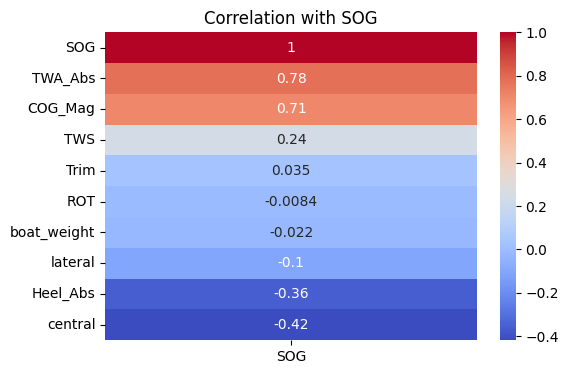


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
COG_Mag,3696.120956,1.0,2293.292416,0.000000e+00,0.139875
TWA_Abs,1411.188627,1.0,875.585029,9.584505e-187,0.058460
TWS,1323.851926,1.0,821.396166,1.241031e-175,0.055041
boat_weight,768.032388,1.0,476.532795,6.329258e-104,0.032687
Heel_Abs,340.693133,1.0,211.386204,1.511103e-47,0.014768
lateral,51.839291,1.0,32.164167,1.444606e-08,0.002276
ROT,5.012642,1.0,3.110140,7.782791e-02,0.000220
Trim,2.485182,1.0,1.541954,2.143479e-01,0.000109
central,1.036450,1.0,0.643075,4.226131e-01,0.000046
Residual,22728.326033,14102.0,NaN,NaN,0.500000



Polynomial fit:
R²: 0.682

Top coefficients:
    feature  coefficient
boat_weight    -1.463730
        TWS     0.164297
    COG_Mag     0.048523
    lateral    -0.042502
    TWA_Abs     0.035710
   Heel_Abs    -0.033576
       Trim     0.004556
        ROT    -0.001631
    central    -0.000945


,feature,coefficient
8,boat_weight,-1.463730
0,TWS,0.164297
2,COG_Mag,0.048523
4,lateral,-0.042502
7,TWA_Abs,0.035710
3,Heel_Abs,-0.033576
6,Trim,0.004556
5,ROT,-0.001631
1,central,-0.000945


In [25]:
full_analysis(df_numeric_slave_downwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

#### III.3.3. Downwind: Master vs Slave t_test

In [26]:
t_test(df_numeric_master_downwind,df_numeric_slave_downwind)

T-statistic: -7.657, p-value: 0.000000000000020
The difference is statistically significant, keeping data split.
